In [1]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model = model.to(device)

print("Device:", device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Device: cuda


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import segmentation_models_pytorch as smp

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_DIR = "/content/drive/MyDrive/Mammogram_Project/Density_ROI_Dataset"

X = np.load(os.path.join(DATA_DIR, "density_roi_x.npy"))
Y = np.load(os.path.join(DATA_DIR, "density_roi_y.npy"))
D = np.load(os.path.join(DATA_DIR, "density_labels.npy"))

print("Images:", X.shape)
print("Masks:", Y.shape)
print("Density:", D.shape)

Images: (1696, 224, 224)
Masks: (1696, 224, 224)
Density: (1696,)


In [6]:
X_train, X_temp, Y_train, Y_temp, D_train, D_temp = train_test_split(
    X,
    Y,
    D,
    test_size=0.20,
    random_state=42,
    stratify=D
)

X_val, X_test, Y_val, Y_test, D_val, D_test = train_test_split(
    X_temp,
    Y_temp,
    D_temp,
    test_size=0.50,
    random_state=42,
    stratify=D_temp
)

print("Train:", X_train.shape, Y_train.shape, D_train.shape)
print("Val:", X_val.shape, Y_val.shape, D_val.shape)
print("Test:", X_test.shape, Y_test.shape, D_test.shape)

Train: (1356, 224, 224) (1356, 224, 224) (1356,)
Val: (170, 224, 224) (170, 224, 224) (170,)
Test: (170, 224, 224) (170, 224, 224) (170,)


In [7]:
def show_distribution(name, labels):

    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name}")

    for u, c in zip(unique, counts):
        print(f"Density {u}: {c}")


show_distribution("Train", D_train)
show_distribution("Validation", D_val)
show_distribution("Test", D_test)


Train
Density 1: 270
Density 2: 605
Density 3: 359
Density 4: 122

Validation
Density 1: 33
Density 2: 76
Density 3: 45
Density 4: 16

Test
Density 1: 34
Density 2: 76
Density 3: 45
Density 4: 15


In [8]:
X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

Y_train = Y_train.astype(np.float32)
Y_val   = Y_val.astype(np.float32)
Y_test  = Y_test.astype(np.float32)

In [9]:
Y_train = (Y_train > 0).astype(np.float32)
Y_val   = (Y_val > 0).astype(np.float32)
Y_test  = (Y_test > 0).astype(np.float32)

In [10]:
X_train = np.repeat(X_train[..., None], 3, axis=-1)
X_val   = np.repeat(X_val[..., None], 3, axis=-1)
X_test  = np.repeat(X_test[..., None], 3, axis=-1)

Y_train = np.expand_dims(Y_train, axis=1)
Y_val   = np.expand_dims(Y_val, axis=1)
Y_test  = np.expand_dims(Y_test, axis=1)

print(X_train.shape)
print(Y_train.shape)

(1356, 224, 224, 3)
(1356, 1, 224, 224)


In [11]:
class MammogramDataset(Dataset):

    def __init__(self, images, masks, labels):
        self.images = images
        self.masks = masks
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        # HWC -> CHW
        image = torch.tensor(
            self.images[idx].transpose(2, 0, 1),
            dtype=torch.float32
        )

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        )

        density = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return image, mask, density

In [12]:
train_dataset = MammogramDataset(
    X_train,
    Y_train,
    D_train
)

val_dataset = MammogramDataset(
    X_val,
    Y_val,
    D_val
)

test_dataset = MammogramDataset(
    X_test,
    Y_test,
    D_test
)

In [13]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [14]:
images, masks, density = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Density:", density.shape)

Images: torch.Size([8, 3, 224, 224])
Masks: torch.Size([8, 1, 224, 224])
Density: torch.Size([8])


In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [16]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model = model.to(device)

print("DeepLabV3+ loaded successfully")

DeepLabV3+ loaded successfully


In [17]:
images, masks, density = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input:", images.shape)
print("Output:", outputs.shape)
print("Mask:", masks.shape)

Input: torch.Size([8, 3, 224, 224])
Output: torch.Size([8, 1, 224, 224])
Mask: torch.Size([8, 1, 224, 224])


In [18]:
class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (
            2.0 * intersection + 1e-6
        ) / (
            probs.sum() + targets.sum() + 1e-6
        )

        return 1 - dice

In [19]:
class BCEDiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):

        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        return bce_loss + dice_loss


criterion = BCEDiceLoss()

In [20]:
def calculate_metrics(outputs, masks, threshold=0.5, smooth=1e-6):

    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()

    preds = preds.view(-1)
    masks = masks.view(-1)

    TP = (preds * masks).sum()
    FP = (preds * (1 - masks)).sum()
    FN = ((1 - preds) * masks).sum()
    TN = ((1 - preds) * (1 - masks)).sum()

    accuracy = (
        TP + TN + smooth
    ) / (
        TP + TN + FP + FN + smooth
    )

    precision = (
        TP + smooth
    ) / (
        TP + FP + smooth
    )

    recall = (
        TP + smooth
    ) / (
        TP + FN + smooth
    )

    f1 = (
        2 * precision * recall + smooth
    ) / (
        precision + recall + smooth
    )

    iou = (
        TP + smooth
    ) / (
        TP + FP + FN + smooth
    )

    dice = (
        2 * TP + smooth
    ) / (
        2 * TP + FP + FN + smooth
    )

    return (
        accuracy.item(),
        precision.item(),
        recall.item(),
        f1.item(),
        iou.item(),
        dice.item()
    )

In [21]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

EPOCHS = 50

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [22]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

best_dice = 0.0
patience = 10
counter = 0

SAVE_PATH = (
    "/content/drive/MyDrive/Mammogram_Project/"
    "DeepLabV3Plus_best.pth"
)

In [23]:
from tqdm import tqdm
from torch.amp import autocast, GradScaler

# Mixed precision
scaler = GradScaler("cuda")

best_dice = 0.0
patience = 10
counter = 0

EPOCHS = 50

# Store history for plotting later
history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": [],
    "train_acc": [],
    "val_acc": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": []
}


for epoch in range(EPOCHS):

    ########################################
    # TRAINING
    ########################################

    model.train()

    train_loss = 0
    train_acc = 0
    train_prec = 0
    train_rec = 0
    train_f1 = 0
    train_iou = 0
    train_dice = 0


    for images, masks, density in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"
    ):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        # Mixed precision training
        with autocast("cuda"):

            # DeepLabV3+ directly returns logits
            logits = model(images)

            loss = criterion(
                logits,
                masks
            )

        # Backpropagation
        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()


        # Loss
        train_loss += loss.item()


        # Metrics
        acc, prec, rec, f1, iou, dice = calculate_metrics(
            logits.detach(),
            masks
        )

        train_acc += acc
        train_prec += prec
        train_rec += rec
        train_f1 += f1
        train_iou += iou
        train_dice += dice


    # Average training metrics

    train_loss /= len(train_loader)

    train_acc /= len(train_loader)
    train_prec /= len(train_loader)
    train_rec /= len(train_loader)
    train_f1 /= len(train_loader)
    train_iou /= len(train_loader)
    train_dice /= len(train_loader)


    ########################################
    # VALIDATION
    ########################################

    model.eval()

    val_loss = 0
    val_acc = 0
    val_prec = 0
    val_rec = 0
    val_f1 = 0
    val_iou = 0
    val_dice = 0


    with torch.no_grad():

        for images, masks, density in tqdm(
            val_loader,
            desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"
        ):

            images = images.to(device)
            masks = masks.to(device)


            # Forward pass
            logits = model(images)


            # Loss
            loss = criterion(
                logits,
                masks
            )

            val_loss += loss.item()


            # Metrics
            acc, prec, rec, f1, iou, dice = calculate_metrics(
                logits,
                masks
            )

            val_acc += acc
            val_prec += prec
            val_rec += rec
            val_f1 += f1
            val_iou += iou
            val_dice += dice


    # Average validation metrics

    val_loss /= len(val_loader)

    val_acc /= len(val_loader)
    val_prec /= len(val_loader)
    val_rec /= len(val_loader)
    val_f1 /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)


    ########################################
    # LEARNING RATE SCHEDULER
    ########################################

    scheduler.step()


    ########################################
    # SAVE HISTORY
    ########################################

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_prec)
    history["val_precision"].append(val_prec)

    history["train_recall"].append(train_rec)
    history["val_recall"].append(val_rec)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)


    ########################################
    # PRINT RESULTS
    ########################################

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Val Loss : {val_loss:.4f}"
    )

    print(
        f"Train Dice : {train_dice:.4f} | "
        f"Val Dice : {val_dice:.4f}"
    )

    print(
        f"Train IoU : {train_iou:.4f} | "
        f"Val IoU : {val_iou:.4f}"
    )

    print(
        f"Train Acc : {train_acc:.4f} | "
        f"Val Acc : {val_acc:.4f}"
    )

    print(
        f"Train Prec : {train_prec:.4f} | "
        f"Val Prec : {val_prec:.4f}"
    )

    print(
        f"Train Rec : {train_rec:.4f} | "
        f"Val Rec : {val_rec:.4f}"
    )

    print(
        f"Train F1 : {train_f1:.4f} | "
        f"Val F1 : {val_f1:.4f}"
    )


    ########################################
    # SAVE BEST MODEL + EARLY STOPPING
    ########################################

    if val_dice > best_dice:

        best_dice = val_dice
        counter = 0

        torch.save(
            model.state_dict(),
            SAVE_PATH
        )

        print(
            f"Best model saved! "
            f"Validation Dice: {best_dice:.4f}"
        )

    else:

        counter += 1

        print(
            f"Early stopping counter: "
            f"{counter}/{patience}"
        )


    if counter >= patience:

        print("\nEarly stopping triggered!")
        break


print("\nTraining Finished!")
print("Best Validation Dice:", best_dice)

Epoch 1/50 [Val]: 100%|██████████| 22/22 [00:01<00:00, 17.87it/s]



Epoch [1/50]
Train Loss : 0.8645 | Val Loss : 0.9560
Train Dice : 0.7187 | Val Dice : 0.6296
Train IoU : 0.5873 | Val IoU : 0.4615
Train Acc : 0.9149 | Val Acc : 0.9122
Train Prec : 0.6356 | Val Prec : 0.4649
Train Rec : 0.9147 | Val Rec : 0.9858
Train F1 : 0.7187 | Val F1 : 0.6296
Best model saved! Validation Dice: 0.6296


Epoch 2/50 [Val]: 100%|██████████| 22/22 [00:01<00:00, 19.99it/s]



Epoch [2/50]
Train Loss : 0.4327 | Val Loss : 0.6199
Train Dice : 0.8439 | Val Dice : 0.7054
Train IoU : 0.7314 | Val IoU : 0.5460
Train Acc : 0.9746 | Val Acc : 0.9389
Train Prec : 0.8182 | Val Prec : 0.5591
Train Rec : 0.8847 | Val Rec : 0.9628
Train F1 : 0.8439 | Val F1 : 0.7054
Best model saved! Validation Dice: 0.7054


Epoch 3/50 [Val]: 100%|██████████| 22/22 [00:01<00:00, 19.20it/s]


...


Epoch [16/50]
Train Loss : 0.0962 | Val Loss : 0.4599
Train Dice : 0.9412 | Val Dice : 0.7063
Train IoU : 0.8891 | Val IoU : 0.5486
Train Acc : 0.9908 | Val Acc : 0.9646
Train Prec : 0.9403 | Val Prec : 0.9688
Train Rec : 0.9427 | Val Rec : 0.5595
Train F1 : 0.9412 | Val F1 : 0.7063
Early stopping counter: 8/10


Epoch 17/50 [Val]: 100%|██████████| 22/22 [00:01<00:00, 18.27it/s]



Epoch [17/50]
Train Loss : 0.0923 | Val Loss : 0.3622
Train Dice : 0.9436 | Val Dice : 0.7805
Train IoU : 0.8932 | Val IoU : 0.6413
Train Acc : 0.9912 | Val Acc : 0.9707
Train Prec : 0.9429 | Val Prec : 0.9563
Train Rec : 0.9446 | Val Rec : 0.6615
Train F1 : 0.9436 | Val F1 : 0.7805
Early stopping counter: 9/10


Epoch 18/50 [Val]: 100%|██████████| 22/22 [00:01<00:00, 18.12it/s]


Epoch [18/50]
Train Loss : 0.0897 | Val Loss : 0.2220
Train Dice : 0.9450 | Val Dice : 0.8714
Train IoU : 0.8959 | Val IoU : 0.7735
Train Acc : 0.9914 | Val Acc : 0.9794
Train Prec : 0.9444 | Val Prec : 0.8740
Train Rec : 0.9460 | Val Rec : 0.8707
Train F1 : 0.9450 | Val F1 : 0.8714
Early stopping counter: 10/10

Early stopping triggered!

Training Finished!
Best Validation Dice: 0.8726136359301481


In [24]:
model.load_state_dict(
    torch.load(
        SAVE_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best DeepLabV3+ model loaded!")

Best DeepLabV3+ model loaded!


In [25]:
def evaluate_model(loader, model, criterion):

    model.eval()

    total_loss = 0
    total_acc = 0
    total_prec = 0
    total_rec = 0
    total_f1 = 0
    total_iou = 0
    total_dice = 0

    with torch.no_grad():

        for images, masks, density in tqdm(loader):

            images = images.to(device)
            masks = masks.to(device)

            # DeepLabV3+ output
            logits = model(images)

            # Loss
            loss = criterion(logits, masks)

            # Metrics
            acc, prec, rec, f1, iou, dice = calculate_metrics(
                logits,
                masks
            )

            total_loss += loss.item()
            total_acc += acc
            total_prec += prec
            total_rec += rec
            total_f1 += f1
            total_iou += iou
            total_dice += dice

    n = len(loader)

    return {
        "Loss": total_loss / n,
        "Dice": total_dice / n,
        "IoU": total_iou / n,
        "Accuracy": total_acc / n,
        "Precision": total_prec / n,
        "Recall": total_rec / n,
        "F1": total_f1 / n
    }

In [26]:
train_results = evaluate_model(
    train_loader,
    model,
    criterion
)

val_results = evaluate_model(
    val_loader,
    model,
    criterion
)

test_results = evaluate_model(
    test_loader,
    model,
    criterion
)

100%|██████████| 22/22 [00:01<00:00, 16.23it/s]


In [27]:
overall_metrics = pd.DataFrame([
    {
        "Dataset": "Train",
        **train_results
    },
    {
        "Dataset": "Validation",
        **val_results
    },
    {
        "Dataset": "Test",
        **test_results
    }
])

overall_metrics = overall_metrics.round(6)

overall_metrics

,Dataset,Loss,Dice,IoU,Accuracy,Precision,Recall,F1
0,Train,0.134336,0.921596,0.854783,0.987581,0.911196,0.932683,0.921596
1,Validation,0.213496,0.872614,0.775413,0.979393,0.857787,0.889059,0.872614
2,Test,0.205150,0.877121,0.782180,0.980466,0.866272,0.891277,0.877121


In [28]:
def density_metrics(loader, model):

    model.eval()

    all_preds = []
    all_masks = []
    all_density = []

    with torch.no_grad():

        for images, masks, density in loader:

            images = images.to(device)
            masks = masks.to(device)

            # DeepLabV3+ prediction
            logits = model(images)

            # Binary prediction
            preds = (
                torch.sigmoid(logits) > 0.5
            ).float()

            all_preds.append(
                preds.cpu()
            )

            all_masks.append(
                masks.cpu()
            )

            all_density.append(
                density.cpu()
            )

    # Combine batches
    all_preds = torch.cat(all_preds)
    all_masks = torch.cat(all_masks)
    all_density = torch.cat(all_density).numpy()

    results = {}

    for d in sorted(np.unique(all_density)):

        idx = np.where(
            all_density == d
        )[0]

        preds_d = all_preds[idx]
        masks_d = all_masks[idx]

        # calculate_metrics expects logits,
        # so convert binary predictions to logits-like values
        eps = 1e-6

        probs = preds_d.clamp(
            eps,
            1 - eps
        )

        logits_d = torch.log(
            probs / (1 - probs)
        )

        acc, prec, rec, f1, iou, dice = calculate_metrics(
            logits_d,
            masks_d
        )

        results[int(d)] = {
            "Samples": len(idx),
            "Dice": dice,
            "IoU": iou,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        }

    return results

In [29]:
train_density = density_metrics(
    train_loader,
    model
)

val_density = density_metrics(
    val_loader,
    model
)

test_density = density_metrics(
    test_loader,
    model
)

In [30]:
rows = []

for d in [1, 2, 3, 4]:

    rows.append({

        "Density": d,

        "Train Dice":
            train_density[d]["Dice"],

        "Val Dice":
            val_density[d]["Dice"],

        "Test Dice":
            test_density[d]["Dice"],

        "Train IoU":
            train_density[d]["IoU"],

        "Val IoU":
            val_density[d]["IoU"],

        "Test IoU":
            test_density[d]["IoU"]

    })

density_table = pd.DataFrame(rows)

density_table = density_table.round(4)

density_table

,Density,Train Dice,Val Dice,Test Dice,Train IoU,Val IoU,Test IoU
0,1,0.9244,0.8862,0.8713,0.8594,0.7956,0.7719
1,2,0.9253,0.8748,0.8753,0.8610,0.7775,0.7783
2,3,0.9192,0.8668,0.8794,0.8505,0.7649,0.7847
3,4,0.9158,0.8679,0.8745,0.8447,0.7666,0.7770


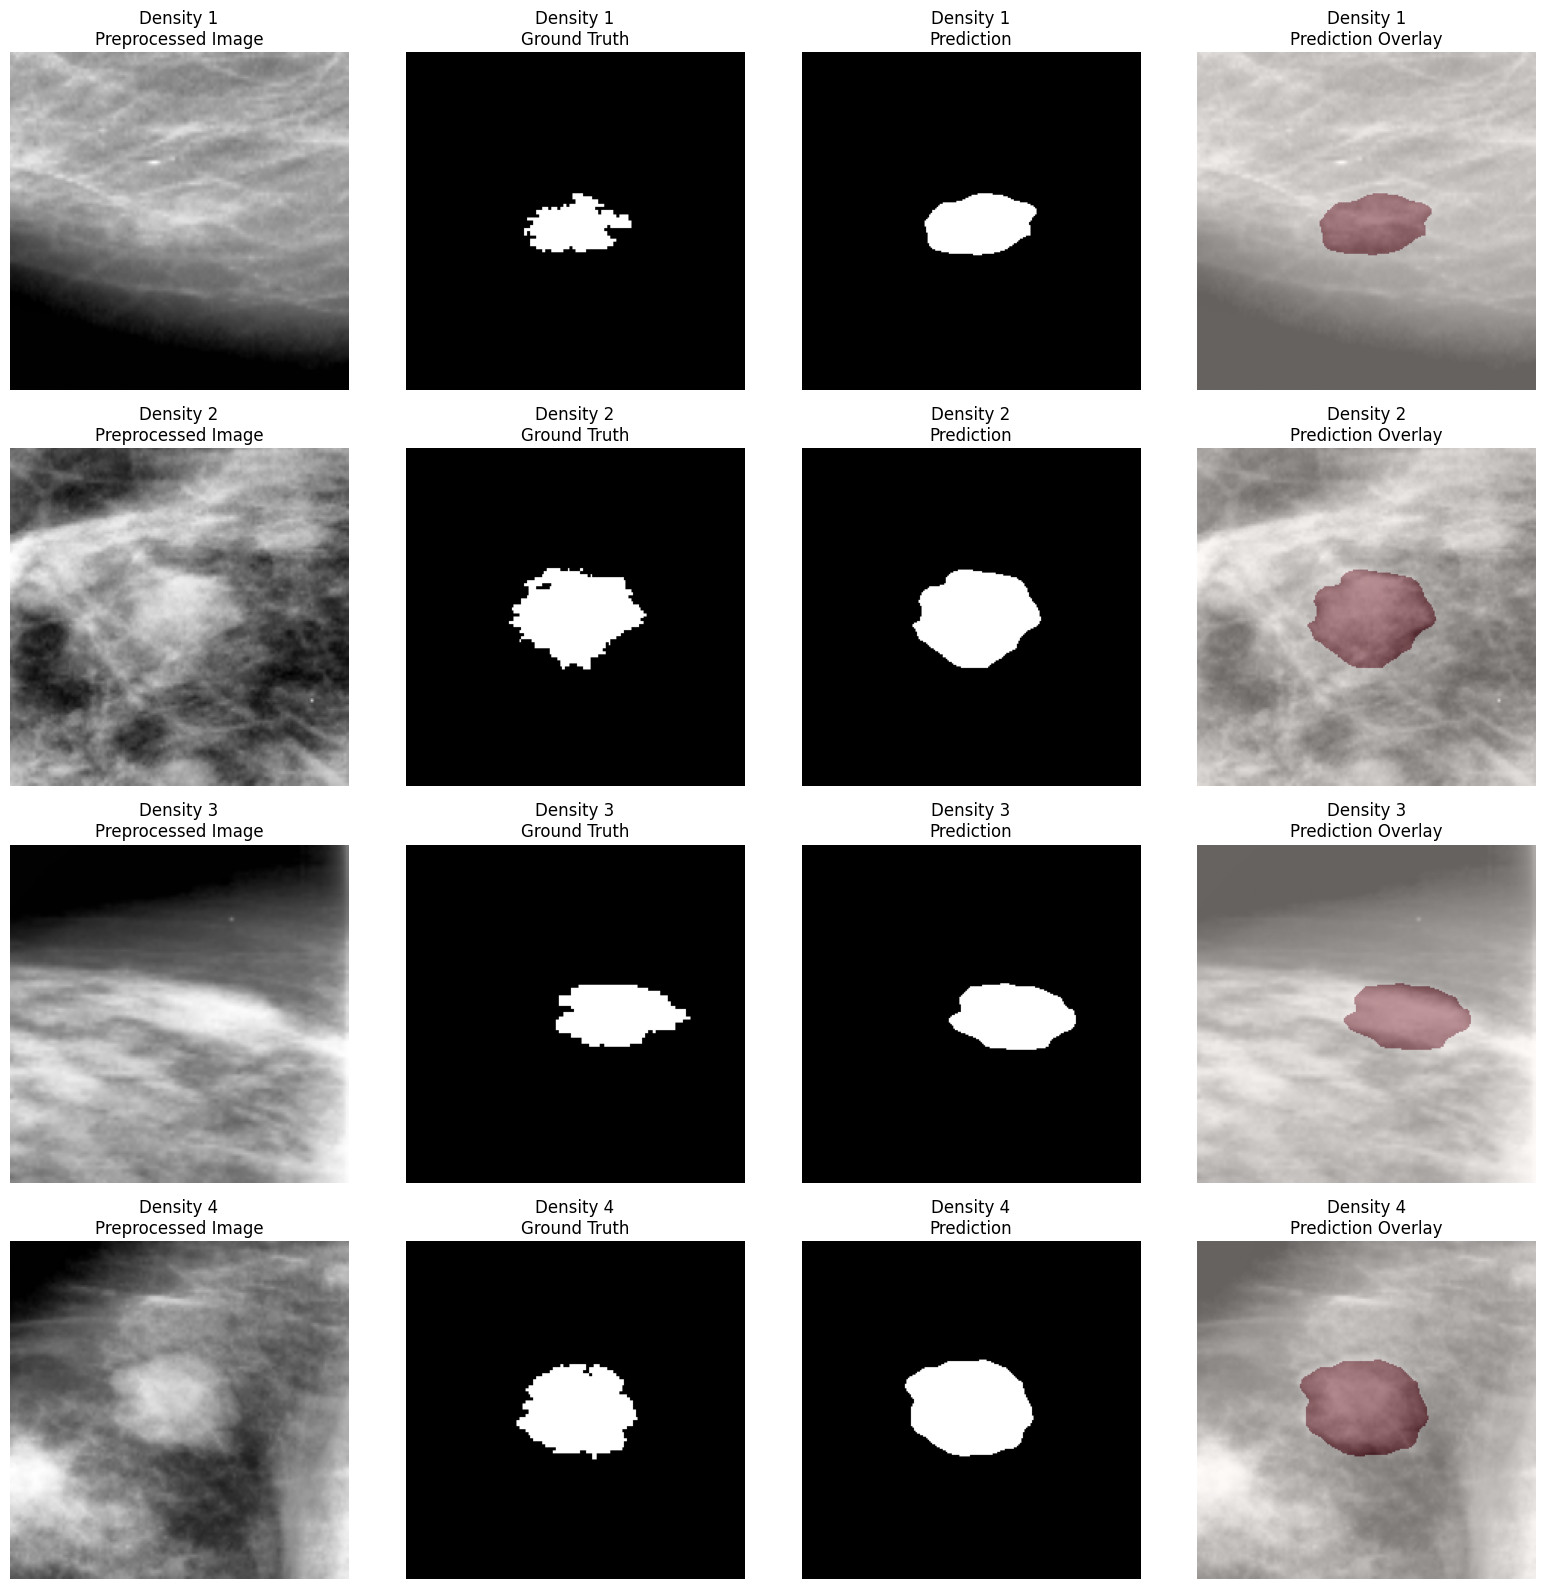

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for row, d in enumerate([1, 2, 3, 4]):

    # Find one test sample belonging to this density
    idx = np.where(D_test == d)[0][0]

    # Get image and mask
    image = X_test[idx]
    mask = Y_test[idx]

    # Convert image to tensor: HWC -> CHW
    image_tensor = torch.tensor(
        image.transpose(2, 0, 1),
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        logits = model(image_tensor)

        pred = (
            torch.sigmoid(logits) > 0.5
        ).float()

    pred = pred.squeeze().cpu().numpy()
    mask = mask.squeeze()

    # Grayscale image for visualization
    image_gray = image[:, :, 0]

    # -------------------------
    # Preprocessed Image
    # -------------------------
    axes[row, 0].imshow(
        image_gray,
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"Density {d}\nPreprocessed Image"
    )

    axes[row, 0].axis("off")


    # -------------------------
    # Ground Truth
    # -------------------------
    axes[row, 1].imshow(
        mask,
        cmap="gray"
    )

    axes[row, 1].set_title(
        f"Density {d}\nGround Truth"
    )

    axes[row, 1].axis("off")


    # -------------------------
    # Prediction
    # -------------------------
    axes[row, 2].imshow(
        pred,
        cmap="gray"
    )

    axes[row, 2].set_title(
        f"Density {d}\nPrediction"
    )

    axes[row, 2].axis("off")


    # -------------------------
    # Overlay
    # -------------------------
    axes[row, 3].imshow(
        image_gray,
        cmap="gray"
    )

    axes[row, 3].imshow(
        pred,
        alpha=0.4,
        cmap="Reds"
    )

    axes[row, 3].set_title(
        f"Density {d}\nPrediction Overlay"
    )

    axes[row, 3].axis("off")


plt.tight_layout()
plt.show()